In [70]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS (run once after kernel restart)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import os


In [71]:
import spikeinterface.full as si
import os

# ----------------------------
# AUTO-DETECT OPEN EPHYS ROOT
# ----------------------------

# You only specify the kilosort folder
kilosort_path = r"C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

# Walk upward until we find the session root (folder containing "Record Node ...")
def find_session_root(path):
    path = os.path.abspath(path)
    while True:
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not find session root containing 'Record Node ...'")
        # Look for any folder named "Record Node XXX"
        if any("Record Node" in d for d in os.listdir(parent)):
            return parent
        path = parent

raw_data_path = find_session_root(kilosort_path)

print("Detected session root:", raw_data_path)

# Analyzer output folder
analyzer_path = os.path.join(raw_data_path, "sorting_analyzer_output")
os.makedirs(analyzer_path, exist_ok=True)

print("Analyzer output folder:", analyzer_path)

# ----------------------------
# VERIFY + LOAD RECORDING
# ----------------------------

print("\n=== PATH VERIFICATION ===")
print("Session folder exists:", os.path.isdir(raw_data_path))

channel_ids = recording.get_channel_ids()

record_nodes = [f for f in os.listdir(raw_data_path) if "Record Node" in f]
print("Record Nodes found:", record_nodes)

for rn in record_nodes:
    oebin_path = os.path.join(raw_data_path, rn, "experiment1", "recording1", "structure.oebin")
    print(f"Checking {oebin_path}: exists =", os.path.isfile(oebin_path))

print("\nLoading Neuropixels stream...")
recording = si.read_openephys(raw_data_path, stream_id='0')
recording = si.scale(recording)

print("Loaded recording:")
print(recording)
print("Sampling rate:", recording.sampling_frequency)
print("Num channels:", recording.get_num_channels())


Detected session root: C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49
Analyzer output folder: C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\sorting_analyzer_output

=== PATH VERIFICATION ===
Session folder exists: True
Record Nodes found: ['Record Node 101', 'Record Node 104']
Checking C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\structure.oebin: exists = True
Checking C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 104\experiment1\recording1\structure.oebin: exists = True

Loading Neuropixels stream...
Loaded recording:
ScaleRecording: 384 channels - 30.0kHz - 1 segments - 68,282,811 samples 
                2,276.09s (37.93 minutes) - float32 dtype - 97.68 GiB
Sampling rate: 30000.0
Num channels: 384


In [3]:
# ============================================================
# CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION (run once)
# ============================================================

print("Loading sorting...")
sorting = si.read_kilosort(kilosort_path)

print("Creating analyzer...")

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording,
    folder=analyzer_path,
    format="binary_folder",
    overwrite=True
)

print("Computing FEATURES (run once)...")

analyzer.compute("random_spikes", max_spikes_per_unit=300)
analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0)
analyzer.compute("templates")
analyzer.compute("noise_levels")

print("Feature extraction complete and cached.")


Loading sorting...
Creating analyzer...


estimate_sparsity (no parallelization):   0%|          | 0/2277 [00:00<?, ?it/s]

Computing FEATURES (run once)...


compute_waveforms (no parallelization):   0%|          | 0/2277 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

Feature extraction complete and cached.


In [72]:
# ============================================================
# CELL 3 — LOAD CACHED FEATURES (safe + self-verifying)
# ============================================================

print("Loading cached SpikeInterface features...")

# --- Verify analyzer exists ---
try:
    analyzer
except NameError:
    raise RuntimeError("ERROR: 'analyzer' is not defined. "
                       "Did you run Cell 2 (feature extraction) first?")

# --- Load extensions safely ---
try:
    wfs_ext = analyzer.get_extension("waveforms")
    templ_ext = analyzer.get_extension("templates")
    noise_ext = analyzer.get_extension("noise_levels")
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to load one or more extensions: {e}")

# --- Extract data ---
try:
    templates = templ_ext.get_data()
    noise = noise_ext.get_data()
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to extract template/noise data: {e}")

# --- Basic sanity checks ---
print("\n=== FEATURE LOAD SUMMARY ===")

print("Templates loaded:", isinstance(templates, np.ndarray))
print("Noise loaded:", isinstance(noise, np.ndarray))

print("Template array shape:", templates.shape)
print("Noise array shape:", noise.shape)

print("Number of units:", len(sorting.unit_ids))

# Check for obvious corruption
if templates.shape[0] != len(sorting.unit_ids):
    raise RuntimeError("ERROR: Number of templates does not match number of units!")

if noise.ndim != 1:
    raise RuntimeError("ERROR: Noise array should be 1D (per-channel).")

print("\nAll cached features loaded successfully ✔️")


Loading cached SpikeInterface features...

=== FEATURE LOAD SUMMARY ===
Templates loaded: True
Noise loaded: True
Template array shape: (428, 90, 384)
Noise array shape: (384,)
Number of units: 428

All cached features loaded successfully ✔️


Computing SNR and amplitude QC from cached features...

=== AMPLITUDE FILTER RESULTS ===
Valid units (< 750.0 µV): 408
Artifact units (≥ 750.0 µV): 20

=== SNR QC SUMMARY (best channel) ===
Median noise (µV): 44.349082946777344
Median template peak (µV): 87.66548156738281
Median SNR: 1.9710729008452375

First 5 units:
Unit 0: best_ch=23, amp=1524.3 µV, noise=32.1 µV, SNR=47.41
Unit 1: best_ch=36, amp=93.7 µV, noise=44.3 µV, SNR=2.11
Unit 2: best_ch=36, amp=87.4 µV, noise=44.3 µV, SNR=1.97
Unit 3: best_ch=36, amp=123.4 µV, noise=44.3 µV, SNR=2.78
Unit 4: best_ch=36, amp=100.2 µV, noise=44.3 µV, SNR=2.26


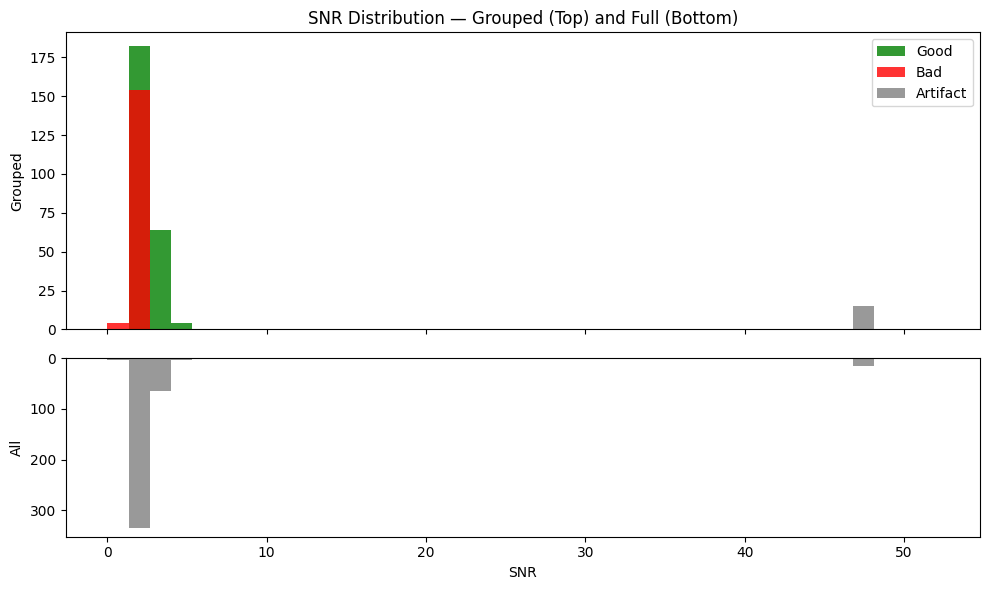

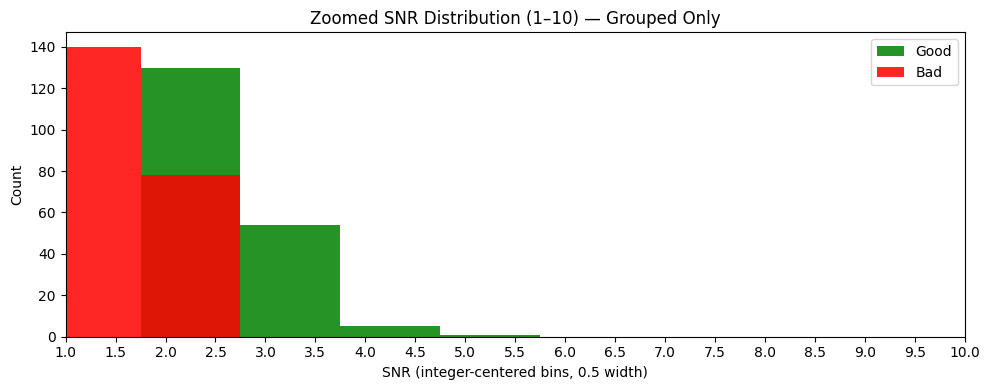


=== SNR QC CLASSIFICATION ===
SNR good units (1.9–10): 216
SNR bad units (<=1.89 or >=10.01): 192
Artifact units (amp >= 750 µV): 20

First 5 SNR-good units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
First 5 SNR-bad units: [np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14)]
First 5 artifact units: [np.int64(0), np.int64(43), np.int64(46), np.int64(85), np.int64(90)]


In [73]:
# ============================================================
# CELL 4 — SNR + AMPLITUDE QC (modular, uses cached features)
# ============================================================

print("Computing SNR and amplitude QC from cached features...")

unit_best_ch = {}
unit_amp = {}
unit_noise = {}
unit_snr = {}

for i, uid in enumerate(sorting.unit_ids):
    templ = templates[i]

    # --- Best channel = most negative peak ---
    if templ.ndim == 1:
        best_ch = 0
        neg_peak = -np.min(templ)
    else:
        neg_peaks = -np.min(templ, axis=0)
        best_ch = int(np.argmax(neg_peaks))
        neg_peak = float(neg_peaks[best_ch])

    noise_best = float(noise[best_ch])
    snr = neg_peak / noise_best if noise_best > 0 else np.nan

    unit_best_ch[uid] = best_ch
    unit_amp[uid] = neg_peak
    unit_noise[uid] = noise_best
    unit_snr[uid] = snr


# ============================================================
# FILTER OUT RIDICULOUSLY LARGE AMPLITUDE UNITS (≥ 750 µV)
# ============================================================

amp_cutoff_uv = 750.0 ########################################################################################################################################################################################################

valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]

print("\n=== AMPLITUDE FILTER RESULTS ===")
print(f"Valid units (< {amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥ {amp_cutoff_uv} µV): {len(artifact_units)}")

# ============================================================
# SUMMARY STATISTICS
# ============================================================

amps_all = np.array(list(unit_amp.values()))
snrs_all = np.array(list(unit_snr.values()))
noise_all = np.array(list(unit_noise.values()))

print("\n=== SNR QC SUMMARY (best channel) ===")
print("Median noise (µV):", float(np.median(noise_all)))
print("Median template peak (µV):", float(np.median(amps_all)))
print("Median SNR:", float(np.nanmedian(snrs_all)))

print("\nFirst 5 units:")
for uid in sorting.unit_ids[:5]:
    print(f"Unit {uid}: best_ch={unit_best_ch[uid]}, amp={unit_amp[uid]:.1f} µV, "
          f"noise={unit_noise[uid]:.1f} µV, SNR={unit_snr[uid]:.2f}")

# ============================================================
# TWO-PART SNR HISTOGRAM (GROUPED ABOVE, FULL BELOW)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

snr_threshold = 1.8  # define your "good" threshold#########################################################################################################################################################

# Extract SNRs by category
snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] < snr_threshold])
snr_artifact = np.array([unit_snr[uid] for uid in artifact_units])

snr_all = np.array(list(unit_snr.values()))

# Shared bins
bins = np.linspace(0, max(snr_all) * 1.1, 40)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 0.6]}
)

# -------------------------
# TOP PANEL — GROUPED HISTOGRAM
# -------------------------
ax_top.hist(snr_good, bins=bins, color='green', alpha=0.8, label='Good')
ax_top.hist(snr_bad, bins=bins, color='red', alpha=0.8, label='Bad')
ax_top.hist(snr_artifact, bins=bins, color='gray', alpha=0.8, label='Artifact')

ax_top.set_ylabel("Grouped")
ax_top.set_title("SNR Distribution — Grouped (Top) and Full (Bottom)")
ax_top.legend(loc='upper right')

# -------------------------
# BOTTOM PANEL — FULL HISTOGRAM (INVERTED)
# -------------------------
ax_bottom.hist(snr_all, bins=bins, color='black', alpha=0.4)
ax_bottom.invert_yaxis()
ax_bottom.set_ylabel("All")
ax_bottom.set_xlabel("SNR")

plt.tight_layout()
plt.show()

# ============================================================
# ZOOMED GROUPED SNR HISTOGRAM (1–10, 0.5-wide bins)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

snr_threshold = 2.0  # same threshold as before

# Extract SNRs for valid units only
snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad  = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] <  snr_threshold])

# 0.5-wide bins centered on integers 1–10
# Example: bin for "2" spans 1.75–2.25
centers = np.arange(1, 11, 1)
bins = centers - 0.25
bins = np.append(bins, centers[-1] + 0.25)

plt.figure(figsize=(10, 4))

plt.hist(snr_good, bins=bins, color='green', alpha=0.85, label='Good')
plt.hist(snr_bad,  bins=bins, color='red',   alpha=0.85, label='Bad')

plt.xticks(np.arange(1, 11, 0.5))  # 0.5 tick spacing
plt.xlim(1, 10)

plt.xlabel("SNR (integer-centered bins, 0.5 width)")
plt.ylabel("Count")
plt.title("Zoomed SNR Distribution (1–10) — Grouped Only")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================================
# CLASSIFY UNITS BY SNR
# ============================================================

snr_good_units = []
snr_bad_units = []

for uid in valid_units:  # only evaluate non-artifact units
    snr_val = unit_snr[uid]

    if 1.9 <= snr_val <= 10.0:
        snr_good_units.append(uid)
    else:
        snr_bad_units.append(uid)

print("\n=== SNR QC CLASSIFICATION ===")
print(f"SNR good units (1.9–10): {len(snr_good_units)}")
print(f"SNR bad units (<=1.89 or >=10.01): {len(snr_bad_units)}")
print(f"Artifact units (amp >= 750 µV): {len(artifact_units)}")

# Optional: print first few for sanity
print("\nFirst 5 SNR-good units:", snr_good_units[:5])
print("First 5 SNR-bad units:", snr_bad_units[:5])
print("First 5 artifact units:", artifact_units[:5])

# ============================================================
# CLASSIFY UNITS BY POSITIVE DEFLECTION
# ============================================================

pos_abs_threshold = 40.0     # µV
pos_ratio_threshold = 0.4    # 40% of negative peak

pos_bad_units = []
pos_good_units = []

for uid in sorting.unit_ids:
    pos_uv = unit_pos_amp[uid]
    ratio = unit_pos_ratio[uid]

    if (pos_uv > pos_abs_threshold) or (ratio > pos_ratio_threshold):
        pos_bad_units.append(uid)
    else:
        pos_good_units.append(uid)


In [74]:
# ============================================================
# POSITIVE DEFLECTION QC — PHY MAIN CHANNEL ONLY
# ============================================================

import numpy as np

# phys_to_template_index: {physical channel ID → template channel index}
# phy_best_ch_id: {unit_id → physical channel ID}
# templates: (n_units, n_samples, n_channels)

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

pos_ratio_threshold = 0.5

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    # Skip if Phy channel not present in templates
    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        unit_pos_amp[uid] = 0.0
        unit_neg_amp[uid] = 0.0
        continue

    main_idx = phys_to_template_index[main_ch_id]

    # Extract waveform on the EXACT channel Phy uses
    trace = templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_neg_amp[uid] = float(neg)
    unit_pos_amp[uid] = float(pos)

    if neg > 0:
        unit_pos_ratio[uid] = float(pos / neg)
    else:
        unit_pos_ratio[uid] = np.inf

# ---- Classification ----
pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")



=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.5): 407
GOOD units (pos/neg <  0.5): 21


In [13]:
# ============================================================
# CELL 5 — SLIM + SAFE ISI + ACG QC
# ============================================================

import numpy as np

print("Computing ISI violations + ACG (memory‑safe)...")

fs = recording.sampling_frequency
rp_ms = 2.0          # refractory period threshold
good_threshold = 0.01  # 1% RPV#####################################################################################################################################################

isi_metrics = {}
acg_metrics = {}

def compute_rpv(st_sec, rp_ms=1.0):
    """Compute refractory period violation rate safely."""
    if st_sec.size < 2:
        return np.nan
    isis = np.diff(st_sec)
    return np.sum(isis < (rp_ms / 1000.0)) / len(isis)

def compute_acg(st_sec, bin_ms=1.0, max_lag_ms=50.0):
    """Memory‑safe sliding‑window ACG."""
    if st_sec.size < 2:
        return np.array([0.0]), np.array([0])

    t_ms = st_sec * 1000.0
    diffs = []
    j0 = 0

    for i in range(len(t_ms)):
        t0 = t_ms[i]

        # Move left pointer
        while j0 < len(t_ms) and t_ms[j0] < t0 - max_lag_ms:
            j0 += 1

        # Move right pointer
        j = j0
        while j < len(t_ms) and t_ms[j] <= t0 + max_lag_ms:
            dt = t_ms[j] - t0
            if dt != 0:
                diffs.append(dt)
            j += 1

    diffs = np.array(diffs)
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_ms, bin_ms)
    acg_counts, edges = np.histogram(diffs, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2.0
    return centers, acg_counts


# ----------------------------
# Loop through units
# ----------------------------
for uid in sorting.unit_ids:

    # Skip amplitude artifacts if desired
    if uid in artifact_units:
        continue

    st_samples = sorting.get_unit_spike_train(uid)
    if st_samples.size < 2:
        isi_metrics[uid] = np.nan
        acg_metrics[uid] = (np.array([0]), np.array([0]))
        continue

    st_sec = st_samples / fs

    # ISI violation rate
    rpv = compute_rpv(st_sec, rp_ms=rp_ms)
    isi_metrics[uid] = rpv

    # ACG
    acg_x, acg_y = compute_acg(st_sec)
    acg_metrics[uid] = (acg_x, acg_y)

# ----------------------------
# Classification
# ----------------------------
good_isi_units = [uid for uid in isi_metrics if isi_metrics[uid] < good_threshold]
bad_isi_units = [uid for uid in isi_metrics if isi_metrics[uid] >= good_threshold]

print("\n=== ISI QC SUMMARY ===")
print(f"Good ISI units (<1% RPV): {len(good_isi_units)}")
print(f"Bad ISI units (>=1% RPV): {len(bad_isi_units)}")

print("\nFirst 5 ISI metrics:")
for uid in list(isi_metrics.keys())[:5]:
    print(f"Unit {uid}: RPV={isi_metrics[uid]:.4f}")


Computing ISI violations + ACG (memory‑safe)...

=== ISI QC SUMMARY ===
Good ISI units (<1% RPV): 334
Bad ISI units (>=1% RPV): 74

First 5 ISI metrics:
Unit 1: RPV=0.0020
Unit 2: RPV=0.0129
Unit 3: RPV=0.0016
Unit 4: RPV=0.0120
Unit 5: RPV=0.0000


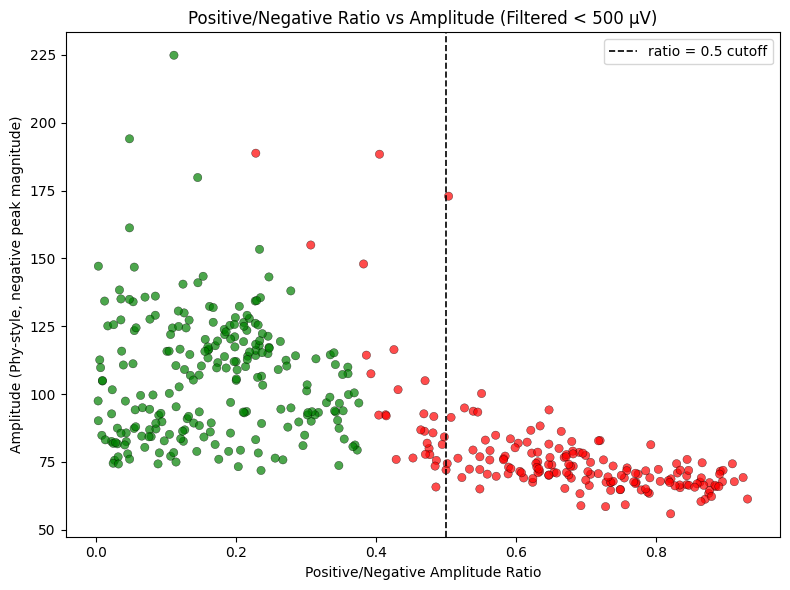

In [29]:
# ============================================================
# PLOT — Ratio (x) vs Amplitude (y), filtering out ≥500 µV
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Filter out large-amplitude units
filtered_uids = [uid for uid in sorting.unit_ids if unit_amp[uid] < 500]

ratios = np.array([unit_pos_ratio[uid] for uid in filtered_uids])
amps   = np.array([unit_amp[uid] for uid in filtered_uids])

# Color by QC classification
colors = []
for uid in filtered_uids:
    if uid in pos_bad_units:
        colors.append("red")
    else:
        colors.append("green")

plt.figure(figsize=(8,6))
plt.scatter(ratios, amps, c=colors, alpha=0.7, edgecolor='k', linewidth=0.3)

# vertical cutoff line at ratio = 0.5
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='ratio = 0.5 cutoff')

plt.xlabel("Positive/Negative Amplitude Ratio")
plt.ylabel("Amplitude (Phy-style, negative peak magnitude)")
plt.title("Positive/Negative Ratio vs Amplitude (Filtered < 500 µV)")

plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# ============================================================
# CELL — UNIFIED QC TABLE (SNR + ISI + POSITIVE DEFLECTION)
# ============================================================

import pandas as pd
import numpy as np

print("Building unified QC table...")

all_units = sorting.unit_ids

rows = []

for uid in all_units:
    amp = unit_amp.get(uid, np.nan)
    snr = unit_snr.get(uid, np.nan)
    noise_val = unit_noise.get(uid, np.nan)
    best_ch = unit_best_ch.get(uid, np.nan)
    isi_rpv = isi_metrics.get(uid, np.nan)

    # Positive deflection metrics (already computed in SNR cell)
    pos_uv = unit_pos_amp.get(uid, np.nan)
    pos_ratio = unit_pos_ratio.get(uid, np.nan)

    # Flags
    is_artifact = uid in artifact_units
    snr_pass = uid in snr_good_units
    isi_pass = uid in good_isi_units
    pos_pass = uid in pos_good_units

    # Final verdict logic
    if is_artifact:
        verdict = "ARTIFACT"
    else:
        if snr_pass and isi_pass and pos_pass:
            verdict = "GOOD"
        elif (snr_pass + isi_pass + pos_pass) >= 1:
            verdict = "CHECK"
        else:
            verdict = "BAD"

    rows.append({
        "unit_id": uid,
        "best_channel": best_ch,
        "amplitude_uv": amp,
        "noise_uv": noise_val,
        "snr": snr,
        "isi_rpv": isi_rpv,
        "pos_amp_uv": pos_uv,
        "pos_ratio": pos_ratio,
        "snr_pass": snr_pass,
        "isi_pass": isi_pass,
        "pos_pass": pos_pass,
        "artifact": is_artifact,
        "final_verdict": verdict
    })

qc_table = pd.DataFrame(rows)
qc_table = qc_table.sort_values("unit_id").reset_index(drop=True)

# ---- ROUND NUMERIC COLUMNS TO 3 DECIMALS ----
qc_table = qc_table.round({
    "amplitude_uv": 3,
    "noise_uv": 3,
    "snr": 3,
    "isi_rpv": 3,
    "pos_amp_uv": 3,
    "pos_ratio": 3
})

print("\n=== QC SUMMARY ===")
print("Total units:", len(qc_table))
print("Artifacts:", (qc_table.final_verdict == "ARTIFACT").sum())
print("GOOD units:", (qc_table.final_verdict == "GOOD").sum())
print("CHECK units:", (qc_table.final_verdict == "CHECK").sum())
print("BAD units:", (qc_table.final_verdict == "BAD").sum())

print("\nFirst 10 rows of QC table:")
display(qc_table.head(10))


Building unified QC table...

=== QC SUMMARY ===
Total units: 428
Artifacts: 20
GOOD units: 150
CHECK units: 244
BAD units: 14

First 10 rows of QC table:


,unit_id,best_channel,amplitude_uv,noise_uv,snr,isi_rpv,pos_amp_uv,pos_ratio,snr_pass,isi_pass,pos_pass,artifact,final_verdict
0,0,23,1524.262,32.149,47.413,NaN,1499.558,0.984,False,False,False,True,ARTIFACT
1,1,36,93.715,44.349,2.113,0.002,50.492,0.539,True,True,False,False,CHECK
2,2,36,87.415,44.349,1.971,0.013,30.344,0.347,True,False,True,False,CHECK
3,3,36,123.424,44.349,2.783,0.002,6.748,0.055,True,True,True,False,GOOD
4,4,36,100.242,44.349,2.260,0.012,55.203,0.551,True,False,False,False,CHECK
5,5,36,93.616,44.349,2.111,0.000,20.122,0.215,True,True,True,False,GOOD
6,6,36,129.078,44.349,2.911,0.000,10.928,0.085,True,True,True,False,GOOD
7,7,36,132.343,44.349,2.984,0.000,21.460,0.162,True,True,True,False,GOOD
8,8,99,84.893,44.942,1.889,0.020,25.299,0.298,False,False,True,False,CHECK
9,9,36,70.484,44.349,1.589,0.002,49.798,0.707,False,True,False,False,CHECK


In [31]:
uid = 389

print("neg_uv:", unit_neg_amp[uid])
print("pos_uv:", unit_pos_amp[uid])
print("pos_ratio:", unit_pos_ratio[uid])

print("is pos_bad?", uid in pos_bad_units)
print("is pos_good?", uid in pos_good_units)


neg_uv: 93.4732666015625
pos_uv: 13.783248901367188
pos_ratio: 0.14745658734833159
is pos_bad? False
is pos_good? True


In [52]:
# ============================================================
# CORRECT MAPPING: UNIT ID → TEMPLATE INDEX (KILOSORT4)
# ============================================================

import numpy as np
from pathlib import Path
from collections import Counter

ks_dir = Path(r"C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4")

# Load Kilosort4 outputs
templates = np.load(ks_dir / "templates.npy")              # (n_templates, n_samples, n_channels)
spike_templates = np.load(ks_dir / "spike_templates.npy")  # (n_spikes,)
spike_clusters = np.load(ks_dir / "spike_clusters.npy")    # (n_spikes,) cluster IDs

print("templates:", templates.shape)
print("spike_templates:", spike_templates.shape)
print("spike_clusters:", spike_clusters.shape)

# ---- 1. For each unit, find the most common template index ----
unit_to_template = {}

for uid in sorting.unit_ids:
    # template indices for spikes belonging to this unit
    t_idx = spike_templates[spike_clusters == uid]
    if len(t_idx) == 0:
        unit_to_template[uid] = None
    else:
        # most common template index = the one Phy uses
        unit_to_template[uid] = int(Counter(t_idx).most_common(1)[0][0])

# ---- 2. Sanity check ----
for uid in list(sorting.unit_ids)[:10]:
    print(f"UID {uid} → template index {unit_to_template[uid]}")


templates: (428, 61, 384)
spike_templates: (38364390,)
spike_clusters: (38364390,)
UID 0 → template index 0
UID 1 → template index 1
UID 2 → template index 2
UID 3 → template index 3
UID 4 → template index 4
UID 5 → template index 5
UID 6 → template index 6
UID 7 → template index 7
UID 8 → template index 8
UID 9 → template index 9


In [54]:
# ============================================================
# LOAD PHY'S MAIN CHANNEL FROM cluster_info.tsv
# ============================================================

import pandas as pd

# Path to your cluster_info.tsv
info = pd.read_csv(
    r"C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4\cluster_info.tsv",
    sep="\t"
)

print("Columns:", info.columns.tolist())

# Detect column names
cluster_col = "cluster_id" if "cluster_id" in info.columns else "id"
channel_col = "ch" if "ch" in info.columns else "channel"

# Build mapping: unit_id → Phy main channel ID (e.g., CH86)
phy_best_ch_id = {
    int(row[cluster_col]): row[channel_col]
    for _, row in info.iterrows()
}

# Sanity check: print first 10 units
for uid in list(phy_best_ch_id.keys())[:10]:
    print(f"UID {uid} → Phy main channel = {phy_best_ch_id[uid]}")


Columns: ['id', 'Amplitude', 'ContamPct', 'KSLabel', 'amp', 'ch', 'depth', 'fr', 'group', 'n_spikes', 'sh']
UID 0 → Phy main channel = 5
UID 1 → Phy main channel = 2
UID 2 → Phy main channel = 2
UID 3 → Phy main channel = 2
UID 4 → Phy main channel = 96
UID 5 → Phy main channel = 101
UID 6 → Phy main channel = 98
UID 7 → Phy main channel = 98
UID 8 → Phy main channel = 99
UID 9 → Phy main channel = 194


In [56]:
# ============================================================
# POSITIVE DEFLECTION QC USING PHY MAIN CHANNEL ± 2 NEIGHBORS
# ============================================================

import numpy as np

# Build mapping: physical channel ID → template channel index
ch_id_to_index = {ch_id: i for i, ch_id in enumerate(channel_ids)}

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

pos_ratio_threshold = 0.5
neighbor_span = 2   # ±2 channels in physical ID space

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    # ---- 1. Build neighbor list ----
    neighbor_ids = [
        main_ch_id + offset
        for offset in range(-neighbor_span, neighbor_span + 1)
        if (main_ch_id + offset) in ch_id_to_index
    ]

    # If no valid neighbors, skip this unit
    if len(neighbor_ids) == 0:
        unit_neg_amp[uid] = 0.0
        unit_pos_amp[uid] = 0.0
        unit_pos_ratio[uid] = np.inf
        continue

    # ---- 2. Convert to template indices ----
    neighbor_indices = [ch_id_to_index[ch] for ch in neighbor_ids]

    # ---- 3. Extract waveforms ----
    wf = templates[uid]  # (time, channels)

    neg_mags = []
    pos_mags = []
    ratios = []

    for idx in neighbor_indices:
        trace = wf[:, idx]
        neg = abs(np.min(trace))
        pos = abs(np.max(trace))

        neg_mags.append(neg)
        pos_mags.append(pos)

        if neg > 0:
            ratios.append(pos / neg)
        else:
            ratios.append(np.inf)

    # ---- 4. Store results ----
    unit_neg_amp[uid] = float(np.max(neg_mags))
    unit_pos_amp[uid] = float(np.max(pos_mags))
    unit_pos_ratio[uid] = float(np.max(ratios))

# ---- 5. Classification ----
pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ± 2) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")



=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ± 2) ===
BAD units (pos/neg >= 0.5): 428
GOOD units (pos/neg <  0.5): 0


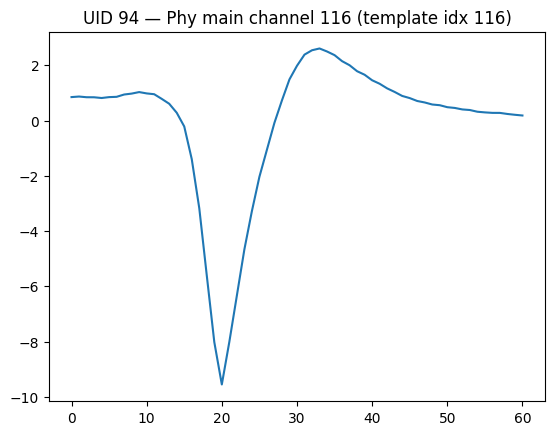

In [59]:
# ============================================================
# PLOT WAVEFORM ON PHY MAIN CHANNEL (CORRECT MAPPING)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Load Kilosort channel_map (physical IDs)
ks_channel_map = np.load(ks_dir / "channel_map.npy")

# Build mapping: physical channel ID → template channel index
phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

uid = 94  # or any unit you want to inspect

main_ch_id = phy_best_ch_id[uid]  # e.g., 86

if main_ch_id not in phys_to_template_index:
    print(f"Phy main channel {main_ch_id} not present in templates.")
else:
    main_idx = phys_to_template_index[main_ch_id]
    wf = templates[uid][:, main_idx]

    plt.plot(wf)
    plt.title(f"UID {uid} — Phy main channel {main_ch_id} (template idx {main_idx})")
    plt.show()


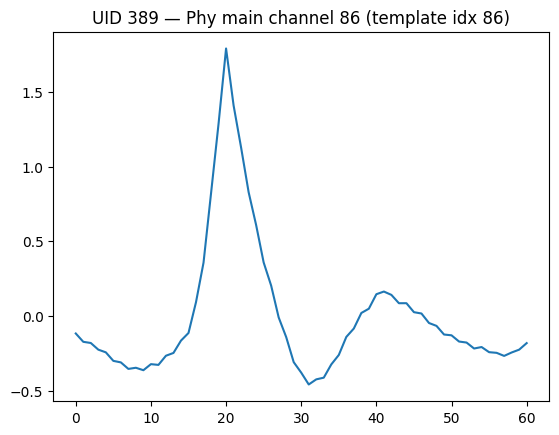

In [60]:
# ============================================================
# PLOT WAVEFORM ON PHY MAIN CHANNEL (CORRECT MAPPING)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Load Kilosort channel_map (physical IDs)
ks_channel_map = np.load(ks_dir / "channel_map.npy")

# Build mapping: physical channel ID → template channel index
phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

uid = 389  # or any unit you want to inspect

main_ch_id = phy_best_ch_id[uid]  # e.g., 86

if main_ch_id not in phys_to_template_index:
    print(f"Phy main channel {main_ch_id} not present in templates.")
else:
    main_idx = phys_to_template_index[main_ch_id]
    wf = templates[uid][:, main_idx]

    plt.plot(wf)
    plt.title(f"UID {uid} — Phy main channel {main_ch_id} (template idx {main_idx})")
    plt.show()


In [69]:
# ============================================================
# POSITIVE DEFLECTION QC — PHY MAIN CHANNEL ONLY
# ============================================================

import numpy as np

# phys_to_template_index: {physical channel ID → template channel index}
# phy_best_ch_id: {unit_id → physical channel ID}
# templates: (n_units, n_samples, n_channels)

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

pos_ratio_threshold = 0.5

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    # Skip if Phy channel not present in templates
    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        unit_pos_amp[uid] = 0.0
        unit_neg_amp[uid] = 0.0
        continue

    main_idx = phys_to_template_index[main_ch_id]

    # Extract waveform on the EXACT channel Phy uses
    trace = templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_neg_amp[uid] = float(neg)
    unit_pos_amp[uid] = float(pos)

    if neg > 0:
        unit_pos_ratio[uid] = float(pos / neg)
    else:
        unit_pos_ratio[uid] = np.inf

# ---- Classification ----
pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")



=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.5): 407
GOOD units (pos/neg <  0.5): 21
